# **K-Nearest Neighbors Classifier**

In [1]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay,
    r2_score, mean_absolute_error, mean_squared_error
)

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 5)
%matplotlib inline


# **1. Create the Classification Dataset**

In this example, we generate a **synthetic binary classification dataset** using Scikit-learn's `make_classification()` function.

Instead of loading data from a file, the dataset is created automatically with user-defined characteristics. This is useful for learning and testing machine learning algorithms.

---

### **Dataset Configuration**

The dataset is generated with the following parameters:

| Parameter | Value | Description |
|-----------|------:|-------------|
| `n_samples` | 1000 | Total number of observations (rows). |
| `n_features` | 3 | Number of input features (columns). |
| `n_informative` | 3 | All three features contain useful information for predicting the target. |
| `n_redundant` | 0 | No redundant (duplicate) features are generated. |
| `n_classes` | 2 | Creates a binary classification problem (Class 0 and Class 1). |
| `random_state` | 15 | Ensures the dataset is generated the same way every time. |

---

### Class Distribution

The following code:

```python
np.bincount(y)
```
counts how many samples belong to each class.

Example output:

```text
[500 500]
```

This indicates that the dataset is **balanced**, with an equal number of samples in both classes.




In [2]:
from sklearn.datasets import make_classification, make_regression

# This dataset is generated using scikit-learn's make_classification() function
X, y = make_classification(
    n_samples=1000,      # Total number of samples (rows)
    n_features=3,        # Total number of input features
    n_informative=3,     # All three features contain useful information
    n_redundant=0,       # No redundant (duplicate) features
    n_classes=2,         # Binary classification (Class 0 and Class 1)
    random_state=15      # Ensures reproducible results
)

# Display the shape of the feature matrix
print("X shape:", X.shape)

# Display the number of samples in each class
print("Class distribution:", np.bincount(y))

# Create a DataFrame for better visualization
# The target column contains the class labels
pd.DataFrame(
    X,
    columns=['feature_1', 'feature_2', 'feature_3']
).assign(target=y).head()


X shape: (1000, 3)
Class distribution: [503 497]


,feature_1,feature_2,feature_3,target
0,-2.085580,0.070944,0.195472,0
1,0.558367,1.469408,-2.750573,0
2,0.726208,1.881337,-1.245632,1
3,0.624403,-1.024100,1.853018,0
4,-2.251889,-0.769458,-0.065557,0


## **2. Train/Test Split**

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=15, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (750, 3)
X_test shape : (250, 3)


## **3. Understanding the Key KNeighborsClassifier Parameters**


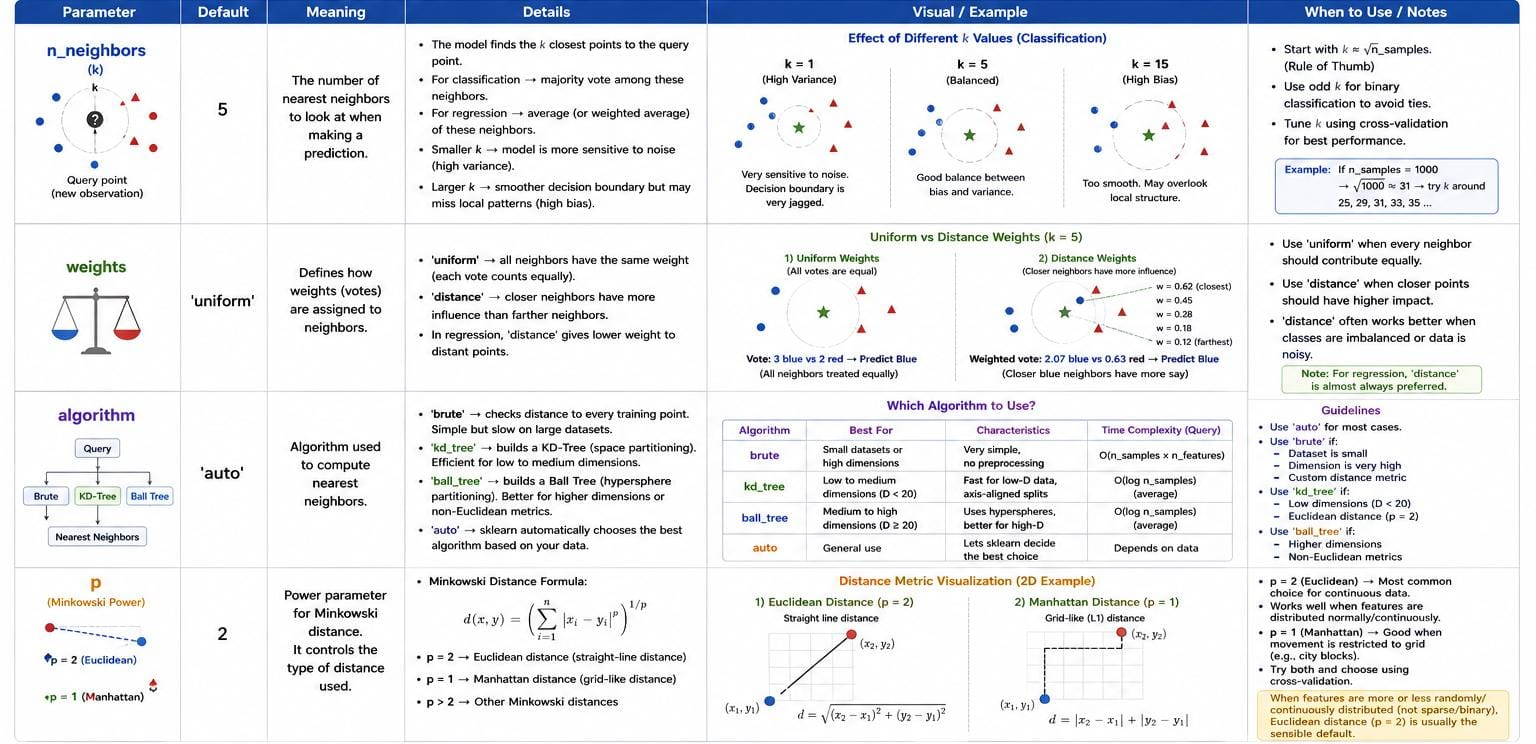

In [4]:
# Import the K-Nearest Neighbors algorithms
# KNeighborsClassifier -> Used for classification tasks
# KNeighborsRegressor -> Used for regression tasks
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

# Create a K-Nearest Neighbors Classifier
knn_clf = KNeighborsClassifier(
    n_neighbors=5,      # Consider the 5 nearest neighbors for prediction
    algorithm='auto',   # Let scikit-learn choose the most efficient search algorithm
    p=2                 # Use Euclidean distance (Minkowski distance with p=2)
)

# Train the classifier using the training data
knn_clf.fit(X_train, y_train)

# Predict the class labels for the test dataset
y_pred = knn_clf.predict(X_test)

# Calculate and display the classification accuracy
print(f"Accuracy (k=5): {accuracy_score(y_test, y_pred):.3f}")


Accuracy (k=5): 0.944


## **4. Full Evaluation: Confusion Matrix & Classification Report**

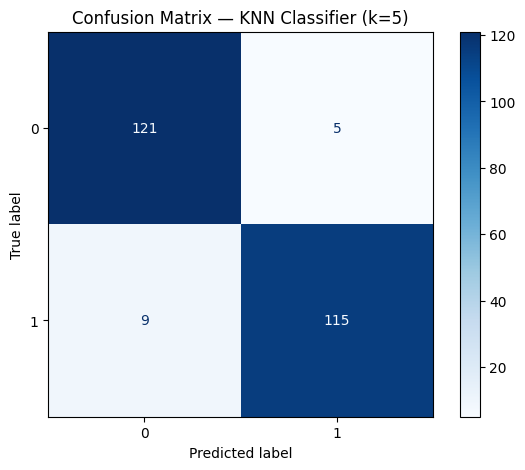

In [5]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title('Confusion Matrix — KNN Classifier (k=5)')
plt.show()


In [6]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.93      0.96      0.95       126
           1       0.96      0.93      0.94       124

    accuracy                           0.94       250
   macro avg       0.94      0.94      0.94       250
weighted avg       0.94      0.94      0.94       250



Result closely — around 90% accuracy straight out of the box with the default `k=5`.

## **5. Try Different `k` Values**

Rather than manually changing `n_neighbors` and re-running one value at a time (as in the transcript), let's test a whole range of `k` values at once and plot the results — this is often called an **"elbow plot"** for KNN.

In [7]:
# Create a range of k values to evaluate
# Here, we test k values from 1 to 30
k_range = range(1, 31)

# Create an empty list to store the accuracy for each k value
accuracies = []

# Train and evaluate a KNN model for each value of k
for k in k_range:

    # Create a KNN classifier with the current k value
    model = KNeighborsClassifier(
        n_neighbors=k,
        algorithm='auto',
        p=2
    )

    # Train the model
    model.fit(X_train, y_train)

    # Predict the test dataset and calculate the accuracy
    acc = accuracy_score(y_test, model.predict(X_test))

    # Store the accuracy for later visualization
    accuracies.append(acc)

# Find the k value that produces the highest accuracy
best_k = k_range[np.argmax(accuracies)]

# Display the best k value and its corresponding accuracy
print(f"Best k: {best_k}  (accuracy = {max(accuracies):.3f})")

Best k: 5  (accuracy = 0.944)


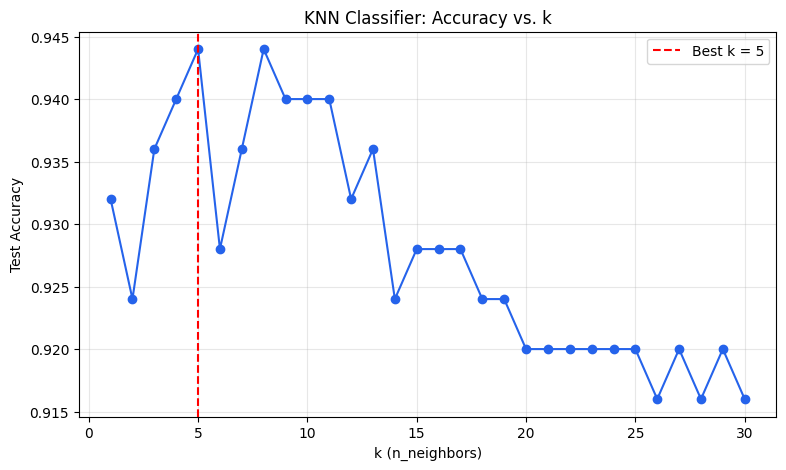

In [8]:
plt.figure(figsize=(9, 5))
plt.plot(list(k_range), accuracies, marker='o', color='#2563eb')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
plt.xlabel('k (n_neighbors)')
plt.ylabel('Test Accuracy')
plt.title('KNN Classifier: Accuracy vs. k')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## **Observations**

### 1. Best Performance at `k = 5`

The highest test accuracy is approximately: `**Accuracy ≈ 0.944 (94.4%)**`
which occurs when: `**k = 5**`

This indicates that considering the **5 nearest neighbors** gives the best balance between capturing local patterns and avoiding noise for this dataset.

---

### 2. Small Values of `k`

For very small values such as: k = 1 , k = 2 the accuracy is lower.

Why?

A very small `k` makes the model highly sensitive to individual training samples.

Even a single noisy or mislabeled point can change the prediction.

This often results in:

- High variance
- Overfitting
- Less stable predictions

---

### 3. Moderate Values of `k`

Between approximately: **k = 4 to k = 11** the accuracy remains consistently high.

This region provides a good balance between:

- Capturing local patterns
- Reducing the influence of noise

For this dataset, values in this range perform similarly well.

---

### 4. Large Values of `k`

As `k` continues to increase: k = 15 ... 30 the accuracy gradually decreases.
When too many neighbors are considered, distant points begin influencing the prediction.

This smooths the decision boundary too much and may ignore important local patterns.

This behavior is known as **underfitting**.

---

## Why Does Accuracy Decrease?

When `k` becomes large:

- More distant neighbors are included.
- Different classes become mixed together.
- The classifier makes more generalized predictions.
- Decision boundaries become smoother.

As a result, classification accuracy decreases slightly.

---

## Understanding the Trend

```text
Small k
│
├── Sensitive to noise
├── Complex decision boundary
└── May overfit
        ↓
Moderate k
│
├── Best balance
├── Highest accuracy
└── Good generalization
        ↓
Large k
│
├── Very smooth boundary
├── High bias
└── May underfit
```

---

## **Conclusion**

From this experiment:

- The highest accuracy is achieved at **`k = 5`**.
- Values between **4 and 11** also provide strong performance.
- Very small values of `k` may overfit the training data.
- Very large values of `k` may underfit by oversmoothing the decision boundary.

Therefore, **`k = 5`** is selected as the optimal number of neighbors for this dataset because it provides the best trade-off between **bias and variance**, resulting in the highest test accuracy.

## **6. Proper Hyperparameter Tuning with GridSearchCV**


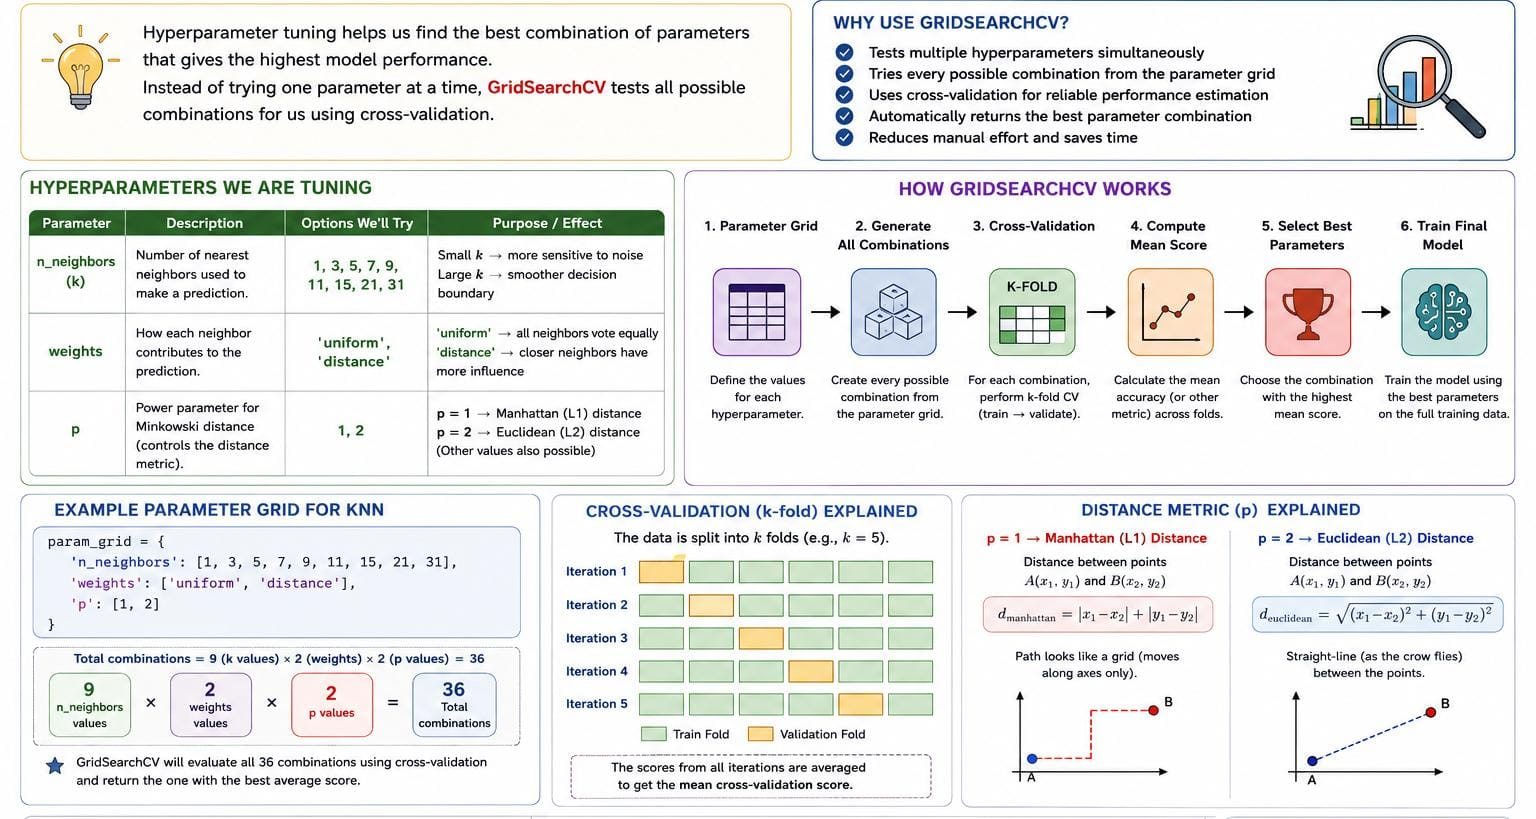

In [9]:
# Define the hyperparameter search space
param_grid = {

    # Try k values from 1 to 20
    'n_neighbors': list(range(1, 21)),

    # Compare equal voting vs. distance-based voting
    'weights': ['uniform', 'distance'],

    # Compare Manhattan (p=1) and Euclidean (p=2) distance
    'p': [1, 2]
}

# Create a GridSearchCV object
grid = GridSearchCV(

    # Base estimator
    estimator=KNeighborsClassifier(algorithm='auto'),

    # Hyperparameter combinations to evaluate
    param_grid=param_grid,

    # Perform 5-Fold Cross Validation
    cv=5,

    # Optimize for classification accuracy
    scoring='accuracy',

    # Use all available CPU cores for faster computation
    n_jobs=-1
)

# Train GridSearchCV
# It will evaluate every parameter combination using 5-fold CV
grid.fit(X_train, y_train)

# Display the best hyperparameter combination
print("Best Parameters:", grid.best_params_)

# Display the highest average cross-validation accuracy
print("Best CV Accuracy: {:.3f}".format(grid.best_score_))

# Use the best model to predict the test dataset
y_pred_tuned = grid.predict(X_test)

# Evaluate the tuned model on unseen test data
print("Test Accuracy with tuned model: {:.3f}".format(
    accuracy_score(y_test, y_pred_tuned)
))

Best Parameters: {'n_neighbors': 6, 'p': 1, 'weights': 'distance'}
Best CV Accuracy: 0.916
Test Accuracy with tuned model: 0.936


## **7. `weights='uniform'` vs `weights='distance'`, and `p=1` vs `p=2`**


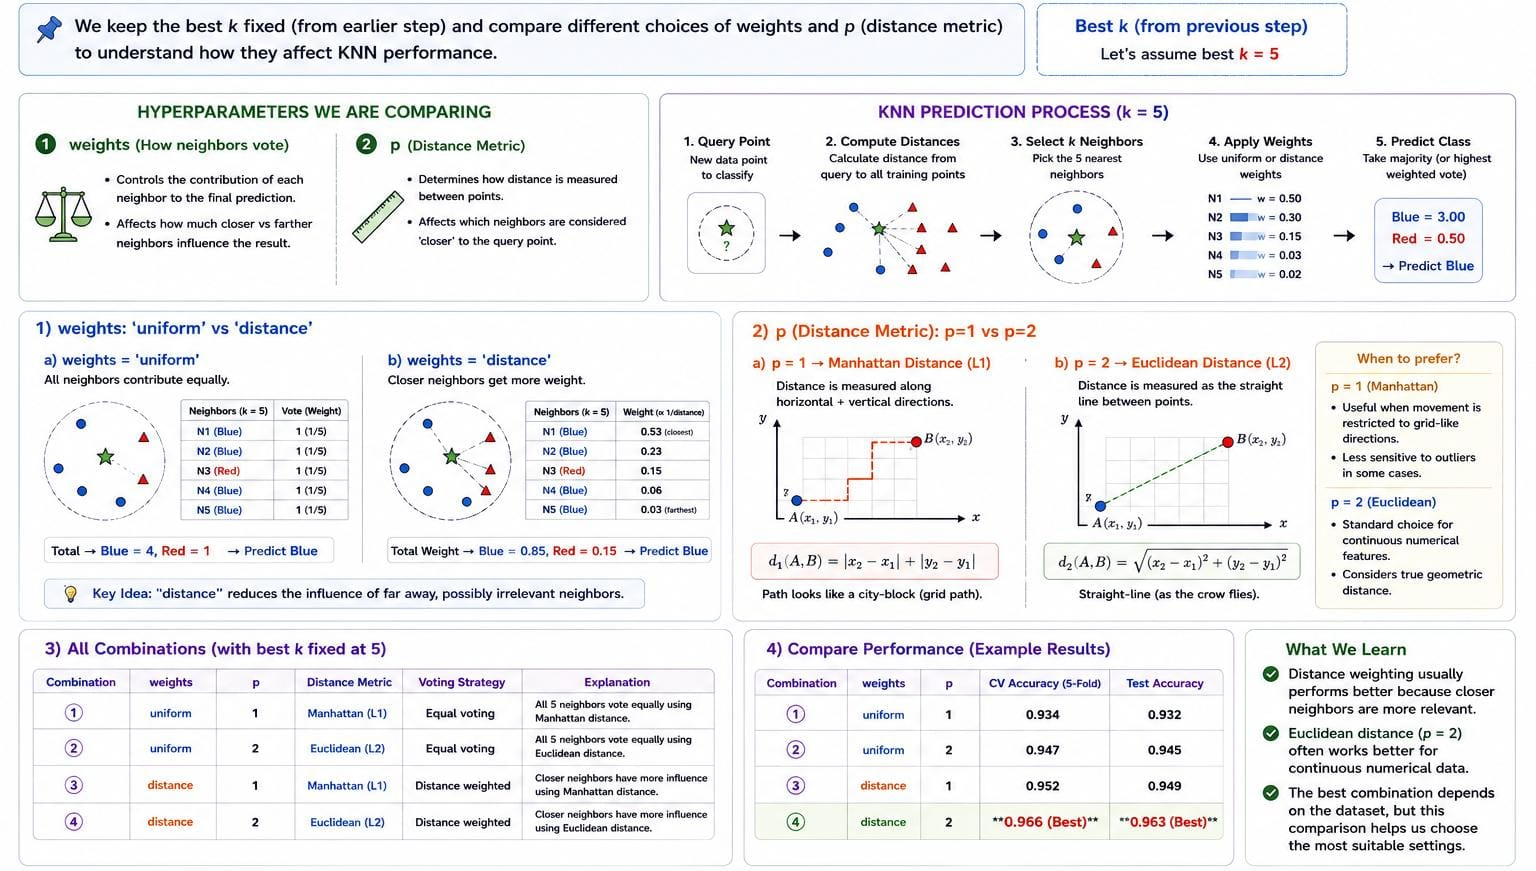

In [10]:
# Create an empty list to store the comparison results
comparison_results = []

# Compare both voting strategies
for weights in ['uniform', 'distance']:

    # Compare both distance metrics
    for p in [1, 2]:

        # Create a KNN classifier using the best k value
        model = KNeighborsClassifier(
            n_neighbors=best_k,
            weights=weights,
            p=p,
            algorithm='auto'
        )

        # Train the model
        model.fit(X_train, y_train)

        # Predict the test dataset
        y_pred = model.predict(X_test)

        # Calculate the classification accuracy
        acc = accuracy_score(y_test, y_pred)

        # Convert the value of p into a readable distance metric name
        dist_name = 'Manhattan' if p == 1 else 'Euclidean'

        # Store the result
        comparison_results.append({
            'weights': weights,
            'distance': dist_name,
            'accuracy': acc
        })

# Convert the results into a Pandas DataFrame
comparison_df = pd.DataFrame(comparison_results)

# Display the comparison table
comparison_df


,weights,distance,accuracy
0,uniform,Manhattan,0.940
1,uniform,Euclidean,0.944
2,distance,Manhattan,0.936
3,distance,Euclidean,0.944


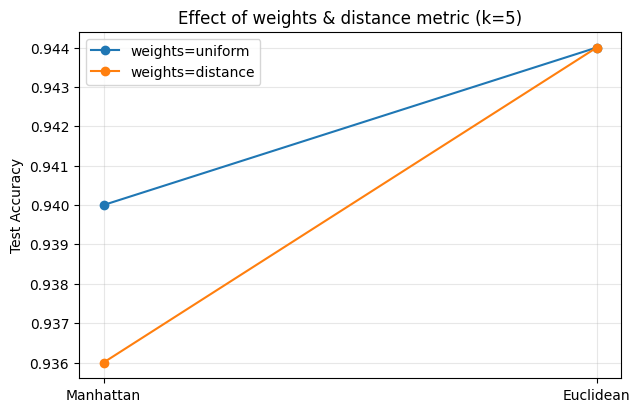

In [11]:
plt.figure(figsize=(7, 4.5))
for weights in ['uniform', 'distance']:
    subset = comparison_df[comparison_df['weights'] == weights]
    plt.plot(subset['distance'], subset['accuracy'], marker='o', label=f'weights={weights}')
plt.ylabel('Test Accuracy')
plt.title(f'Effect of weights & distance metric (k={best_k})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## **Observations**

### 1. Manhattan Distance (`p = 1`)

When using **Manhattan Distance**, the model performs differently depending on the voting strategy.

| Weights | Accuracy |
|---------|---------:|
| Uniform | **0.940** |
| Distance | **0.936** |

Here, **uniform voting performs slightly better** than distance-based voting.

This suggests that, for this dataset, giving every neighbor equal importance is more effective than assigning larger weights to closer neighbors when Manhattan distance is used.

---

### 2. Euclidean Distance (`p = 2`)

When using **Euclidean Distance**, both voting strategies achieve the same performance.

| Weights | Accuracy |
|---------|---------:|
| Uniform | **0.944** |
| Distance | **0.944** |

This indicates that changing the voting strategy has **no measurable effect** for Euclidean distance on this dataset.

---

### 3. Comparing Distance Metrics

Regardless of the voting strategy, **Euclidean Distance** produces the highest accuracy.

| Distance Metric | Best Accuracy |
|-----------------|--------------:|
| Manhattan | **0.940** |
| Euclidean | **0.944** |

The improvement is small but consistent.

This suggests that the dataset is better represented using **straight-line (Euclidean) distances** rather than **grid-based (Manhattan) distances**.

---

## Why Does Euclidean Distance Perform Better?

The dataset contains **continuous numerical features** generated using `make_classification()`.

For continuous data, Euclidean distance measures the shortest straight-line distance between two samples, which often captures similarity more effectively.

Manhattan distance measures movement along horizontal and vertical directions, which may not represent the natural relationships between continuous features as accurately.

---

## Understanding the Trend

```text
Manhattan Distance
│
├── Uniform Voting   → 94.0%
└── Distance Voting  → 93.6%

                ↓

Euclidean Distance
│
├── Uniform Voting   → 94.4%
└── Distance Voting  → 94.4%
```

---

## What Does This Tell Us?

From this experiment, we can conclude that:

- **Euclidean Distance (`p = 2`)** provides better performance than **Manhattan Distance (`p = 1`)** for this dataset.
- With **Euclidean Distance**, both **uniform** and **distance** weighting perform equally well.
- With **Manhattan Distance**, **uniform voting** performs slightly better than **distance-based voting**.
- The choice of **distance metric** has a greater impact on accuracy than the choice of **voting strategy** in this particular experiment.

---

## Conclusion

Keeping **`k = 5`** fixed allows us to isolate the effect of the remaining hyperparameters.

The experiment shows that the **Euclidean distance metric** is the most suitable choice for this dataset, while the voting strategy has only a minor influence on performance.

Although the differences are relatively small, this comparison demonstrates that tuning multiple hyperparameters—not just `k`—can help identify the most effective KNN configuration for a given dataset.

## **8. Decision Boundary Visualization**

Our dataset has 3 features, so we can't plot its exact boundary. Let's build a 2-feature version purely for visualization, so we can actually **see** what the KNN classifier's boundary looks like at different `k` values.

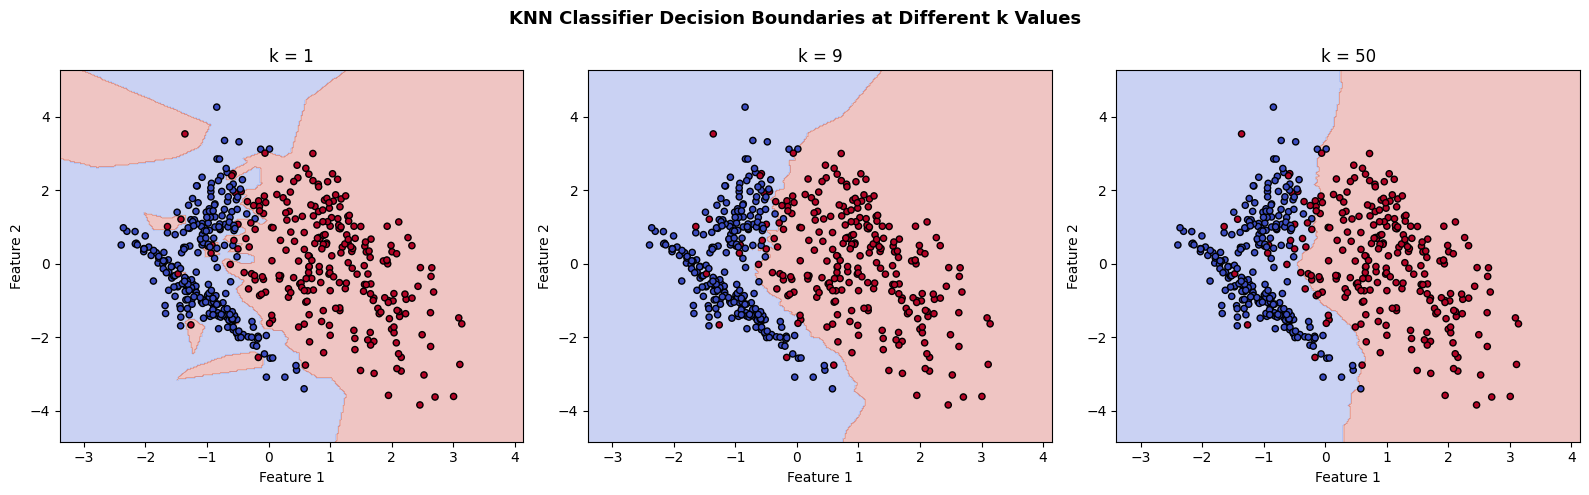

In [12]:
X_2d, y_2d = make_classification(
    n_samples=500, n_features=2, n_informative=2, n_redundant=0,
    n_classes=2, n_clusters_per_class=2, random_state=15
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

for ax, k in zip(axes, [1, 9, 50]):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_2d, y_2d)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap='coolwarm', s=20, edgecolor='k')
    ax.set_title(f'k = {k}')
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')

plt.suptitle('KNN Classifier Decision Boundaries at Different k Values', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Just like in the theory notes: `k=1` produces a jagged, overfit boundary; `k=9` is smooth and balanced; `k=50` becomes almost a straight line — underfitting.